<a href="https://colab.research.google.com/github/RIDDHI1624/Drug-Discovery/blob/main/Insulin_Receptor_Project/phase3_step3_pose_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3, Step 3 — Pose Quality Assessment
## AI Drug Discovery Pipeline · Insulin Receptor (INSR)

**Input:** `phase3_step2_hits.sdf` (GNINA docked poses) + `phase3_candidates.sdf` (Step 1 input) + `synthetic_holo_template.pdb`

**Three checks (pipeline spec):**
- **Step 7:** RMSD comparison — docked pose vs input conformer (< 2Å)
- **Step 8:** Interaction fingerprint — ProLIF (hinge H-bond to Met1079, hydrophobic contacts)
- **Step 9:** Strain energy — RDKit MMFF94 (< 3 kcal/mol)

---
### Before running
1. Upload `phase3_step2_hits.sdf` to Colab files
2. Upload `phase3_candidates.sdf` to Colab files
3. Upload `synthetic_holo_template.pdb` to Colab files
4. Run cells **top to bottom**

---
## 0 · Install Dependencies

In [1]:
%pip install rdkit biopython pandas matplotlib numpy prolif mdanalysis -q
print('✓ Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 142.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.9 MB/s eta 0:00:00
✓ Dependencies installed.


---
## 1 · Imports

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem, SDWriter, rdMolAlign, rdMolDescriptors
from rdkit.Chem import rdForceFieldHelpers
warnings.filterwarnings('ignore')
print('✓ Imports OK.')

✓ Imports OK.


---
## 2 · Configuration

In [3]:
# ── USER SETTINGS ──────────────────────────────────────────────────────────
HITS_SDF       = Path('/content/phase3_step2_hits.sdf')      # GNINA output
INPUT_SDF      = Path('/content/phase3_candidates.sdf')      # Step 1 conformers
PROTEIN_PDB    = Path('/content/synthetic_holo_template.pdb') # INSR structure

# Step 7: RMSD threshold
RMSD_THRESHOLD = 2.0   # Å — pipeline spec

# Step 9: Strain energy threshold
STRAIN_THRESHOLD = 3.0  # kcal/mol — pipeline spec

# Met1079 local residue number (Met185 in your PDB — confirmed from session)
# Val1063 local residue number (Val169 in your PDB)
MET1079_LOCAL = 185
VAL1063_LOCAL = 169
# ────────────────────────────────────────────────────────────────────────────
print(f'Hits SDF    : {HITS_SDF}')
print(f'Input SDF   : {INPUT_SDF}')
print(f'Protein PDB : {PROTEIN_PDB}')
print(f'RMSD threshold   : < {RMSD_THRESHOLD} Å')
print(f'Strain threshold : < {STRAIN_THRESHOLD} kcal/mol')

Hits SDF    : /content/phase3_step2_hits.sdf
Input SDF   : /content/phase3_candidates.sdf
Protein PDB : /content/synthetic_holo_template.pdb
RMSD threshold   : < 2.0 Å
Strain threshold : < 3.0 kcal/mol


---
## 3 · Validate Inputs

In [4]:
errors = []
for path, label in [
    (HITS_SDF,    'Hits SDF (Step 2 output)'),
    (INPUT_SDF,   'Input SDF (Step 1 output)'),
    (PROTEIN_PDB, 'Protein PDB'),
]:
    if not path.exists():
        errors.append(f'✗ {label}: {path}')
    else:
        print(f'✓ {label}: {path.name}')

if errors:
    for e in errors: print(e)
    raise RuntimeError('Upload missing files via left sidebar.')

# Load molecules
hit_mols   = [m for m in Chem.SDMolSupplier(str(HITS_SDF),  removeHs=False) if m is not None]
input_mols = [m for m in Chem.SDMolSupplier(str(INPUT_SDF), removeHs=False) if m is not None]

# Build name→mol lookup for input conformers
input_by_name = {}
for mol in input_mols:
    name = mol.GetProp('_Name') if mol.HasProp('_Name') else ''
    pidx = mol.GetProp('Protomer_index') if mol.HasProp('Protomer_index') else '0'
    if pidx == '0':  # use only the base conformer
        input_by_name[name] = mol

print(f'\nHit molecules  : {len(hit_mols)}')
print(f'Input conformers: {len(input_by_name)}')
print(f'Protein PDB    : {PROTEIN_PDB.stat().st_size/1024:.0f} KB')

✓ Hits SDF (Step 2 output): phase3_step2_hits.sdf
✓ Input SDF (Step 1 output): phase3_candidates.sdf
✓ Protein PDB: synthetic_holo_template.pdb

Hit molecules  : 5
Input conformers: 5
Protein PDB    : 166 KB


---
# STEP 7 · RMSD Comparison
Calculate all-atom RMSD between the GNINA docked pose and the MMFF94-minimised
input conformer from Step 1. RMSD < 2Å = convergent pose (pipeline spec).

In [5]:
def calculate_rmsd(mol_docked, mol_input):
    """
    Calculate all-atom RMSD between docked pose and input conformer.
    Removes Hs, aligns by MCS, returns RMSD in Angstroms.
    """
    try:
        # Remove Hs for alignment
        m1 = Chem.RemoveHs(mol_docked)
        m2 = Chem.RemoveHs(mol_input)

        # Ensure m2 has a 3D conformer
        if m2.GetNumConformers() == 0:
            m2 = Chem.AddHs(m2)
            AllChem.EmbedMolecule(m2, AllChem.ETKDGv3())
            AllChem.MMFFOptimizeMolecule(m2)
            m2 = Chem.RemoveHs(m2)

        # Calculate RMSD using GetBestRMS (handles atom ordering)
        rmsd = AllChem.GetBestRMS(m1, m2)
        return round(rmsd, 3)
    except Exception as e:
        return None


rmsd_results = []
print(f'{"Molecule":20s}  {"RMSD (Å)":>10}  {"< 2Å":>6}  Status')
print('-' * 55)

for mol in hit_mols:
    name  = mol.GetProp('_Name') if mol.HasProp('_Name') else 'unknown'
    score = mol.GetProp('GNINA_CNN_score') if mol.HasProp('GNINA_CNN_score') else 'N/A'

    # Find matching input conformer
    input_mol = input_by_name.get(name)

    if input_mol is None:
        print(f'{name:20s}  {"N/A":>10}  {"N/A":>6}  No input conformer')
        rmsd_results.append({'name': name, 'rmsd': None, 'pass': None, 'cnn': score})
        continue

    rmsd = calculate_rmsd(mol, input_mol)
    if rmsd is None:
        print(f'{name:20s}  {"ERROR":>10}  {"N/A":>6}  Calculation failed')
        rmsd_results.append({'name': name, 'rmsd': None, 'pass': None, 'cnn': score})
        continue

    passed = rmsd < RMSD_THRESHOLD
    status = '✓ CONVERGENT' if passed else '✗ DIVERGENT'
    print(f'{name:20s}  {rmsd:>10.3f}  {str(passed):>6}  {status}')
    rmsd_results.append({'name': name, 'rmsd': rmsd, 'pass': passed, 'cnn': score})

n_pass = sum(1 for r in rmsd_results if r['pass'])
print(f'\nStep 7 result: {n_pass}/{len(rmsd_results)} poses convergent (RMSD < {RMSD_THRESHOLD}Å)')

Molecule                RMSD (Å)    < 2Å  Status
-------------------------------------------------------
candidate_0004             0.090    True  ✓ CONVERGENT
candidate_0001             0.336    True  ✓ CONVERGENT
candidate_0002             0.000    True  ✓ CONVERGENT
candidate_0003             0.753    True  ✓ CONVERGENT
candidate_0005             0.000    True  ✓ CONVERGENT

Step 7 result: 5/5 poses convergent (RMSD < 2.0Å)


---
# STEP 8 · Interaction Fingerprint Analysis
Use ProLIF to enumerate protein-ligand contacts from GNINA docked poses.

**Critical interactions to verify (pipeline spec):**
- ✓ Hinge H-bond to Met1079 (local residue ~Met185)
- ✓ Hydrophobic contacts in allosteric pocket
- ✗ Absence of H-bond to Val1063 (local ~Val169)

In [6]:
try:
    import prolif as plf
    import MDAnalysis as mda
    PROLIF_AVAILABLE = True
    print(f'✓ ProLIF {plf.__version__} available.')
except ImportError:
    PROLIF_AVAILABLE = False
    print('⚠ ProLIF not available — using RDKit-based contact analysis as fallback.')

/usr/local/lib/python3.12/dist-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


✓ ProLIF 2.1.0 available.


In [7]:
from Bio.PDB import PDBParser
import numpy as np

def get_residue_coords(pdb_path, res_num):
    """Get all heavy atom coordinates for a residue."""
    parser    = PDBParser(QUIET=True)
    structure = parser.get_structure('prot', str(pdb_path))
    for model in structure:
        for chain in model:
            for res in chain:
                if res.get_id()[1] == res_num:
                    return np.array([a.get_vector().get_array()
                                     for a in res.get_atoms()
                                     if a.element != 'H'])
    return None


def check_hbond_distance(mol, res_coords, cutoff=3.5):
    """
    Simple distance-based H-bond check.
    Returns True if any ligand atom is within cutoff of any residue atom.
    """
    if res_coords is None or mol.GetNumConformers() == 0:
        return False, 999.0
    conf = mol.GetConformer()
    lig_coords = np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])
    min_dist = 999.0
    for lc in lig_coords:
        for rc in res_coords:
            d = np.linalg.norm(lc - rc)
            if d < min_dist:
                min_dist = d
    return min_dist < cutoff, round(min_dist, 2)


def check_hydrophobic_contacts(mol, pdb_path, cutoff=4.5):
    """
    Count hydrophobic residue contacts within cutoff distance.
    Hydrophobic residues: ALA, VAL, ILE, LEU, MET, PHE, TRP, PRO, TYR
    """
    HYDROPHOBIC = {'ALA','VAL','ILE','LEU','MET','PHE','TRP','PRO','TYR'}
    parser    = PDBParser(QUIET=True)
    structure = parser.get_structure('prot', str(pdb_path))

    if mol.GetNumConformers() == 0:
        return 0, []

    conf = mol.GetConformer()
    lig_coords = np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])
    lig_center = lig_coords.mean(axis=0)

    contacts = []
    for model in structure:
        for chain in model:
            for res in chain:
                if res.get_resname().strip() not in HYDROPHOBIC: continue
                if res.get_id()[0] != ' ': continue
                for atom in res.get_atoms():
                    rc = atom.get_vector().get_array()
                    if np.linalg.norm(lig_center - rc) < cutoff:
                        contacts.append(f"{res.get_resname()}{res.get_id()[1]}")
                        break
    return len(contacts), list(set(contacts))


# Get reference residue coordinates
met1079_coords = get_residue_coords(PROTEIN_PDB, MET1079_LOCAL)
val1063_coords = get_residue_coords(PROTEIN_PDB, VAL1063_LOCAL)

print(f'Met{MET1079_LOCAL} coords: {"found" if met1079_coords is not None else "not found"}')
print(f'Val{VAL1063_LOCAL} coords: {"found" if val1063_coords is not None else "not found"}')

# Analyse each hit
fingerprint_results = []
print(f'\n{"Molecule":20s}  {"Met H-bond":>12}  {"Val absent":>10}  {"Hydrophobic":>11}  Status')
print('-' * 75)

for mol in hit_mols:
    name = mol.GetProp('_Name') if mol.HasProp('_Name') else 'unknown'

    met_hbond, met_dist = check_hbond_distance(mol, met1079_coords, cutoff=3.5)
    val_hbond, val_dist = check_hbond_distance(mol, val1063_coords, cutoff=3.5)
    n_hydro, hydro_res  = check_hydrophobic_contacts(mol, PROTEIN_PDB, cutoff=4.5)

    val_absent = not val_hbond  # pipeline spec: absence of H-bond to Val1063
    step8_pass = met_hbond and val_absent and n_hydro > 0

    status = '✓ PASS' if step8_pass else '✗ FAIL'
    print(f'{name:20s}  {str(met_hbond)+f"({met_dist}Å)":>12}  '
          f'{str(val_absent):>10}  {n_hydro:>11}  {status}')

    fingerprint_results.append({
        'name':        name,
        'met_hbond':   met_hbond,
        'met_dist':    met_dist,
        'val_absent':  val_absent,
        'val_dist':    val_dist,
        'n_hydrophobic': n_hydro,
        'hydro_residues': hydro_res,
        'pass':        step8_pass,
    })

n_pass8 = sum(1 for r in fingerprint_results if r['pass'])
print(f'\nStep 8 result: {n_pass8}/{len(fingerprint_results)} poses pass interaction criteria')

Met185 coords: found
Val169 coords: found

Molecule                Met H-bond  Val absent  Hydrophobic  Status
---------------------------------------------------------------------------
candidate_0004        False(17.84Å)        True            1  ✗ FAIL
candidate_0001        False(17.95Å)        True            3  ✗ FAIL
candidate_0002        False(17.82Å)        True            3  ✗ FAIL
candidate_0003        False(15.64Å)        True            1  ✗ FAIL
candidate_0005        False(12.99Å)        True            2  ✗ FAIL

Step 8 result: 0/5 poses pass interaction criteria


---
# STEP 9 · Strain Energy Calculation
Compare bound conformation (GNINA pose) to lowest-energy unbound conformer (RDKit MMFF94).
Strain energy > 3 kcal/mol suggests the pose may be artifactual (pipeline spec).

In [8]:
def calculate_strain_energy(mol_bound):
    """
    Calculate strain energy = E(bound) - E(unbound_minimum)

    E(bound): MMFF94 energy of docked conformation
    E(unbound): MMFF94 energy after re-minimisation from scratch

    Returns strain energy in kcal/mol, or None on failure.
    """
    try:
        # Add Hs for force field
        mol_h = Chem.AddHs(mol_bound)

        # Ensure 3D conformer exists
        if mol_h.GetNumConformers() == 0:
            AllChem.EmbedMolecule(mol_h, AllChem.ETKDGv3())

        # E(bound) — MMFF94 energy of docked pose
        ff_bound = AllChem.MMFFGetMoleculeForceField(
            mol_h,
            AllChem.MMFFGetMoleculeProperties(mol_h, mmffVariant='MMFF94'),
            confId=0
        )
        if ff_bound is None:
            return None
        e_bound = ff_bound.CalcEnergy()

        # E(unbound) — generate fresh conformer + minimise to global minimum
        mol_free = Chem.RWMol(mol_h)
        mol_free.RemoveAllConformers()
        AllChem.EmbedMolecule(mol_free, AllChem.ETKDGv3())
        ff_free = AllChem.MMFFGetMoleculeForceField(
            mol_free,
            AllChem.MMFFGetMoleculeProperties(mol_free, mmffVariant='MMFF94'),
            confId=0
        )
        if ff_free is None:
            return None
        ff_free.Minimize(maxIts=2000)
        e_unbound = ff_free.CalcEnergy()

        strain = e_bound - e_unbound
        return round(strain, 2)

    except Exception as e:
        return None


strain_results = []
print(f'{"Molecule":20s}  {"E_bound":>10}  {"E_unbound":>10}  {"Strain":>8}  {"<3 kcal":>8}  Status')
print('-' * 78)

for mol in hit_mols:
    name = mol.GetProp('_Name') if mol.HasProp('_Name') else 'unknown'

    # Get energies
    mol_h = Chem.AddHs(mol)
    if mol_h.GetNumConformers() == 0:
        AllChem.EmbedMolecule(mol_h, AllChem.ETKDGv3())

    props = AllChem.MMFFGetMoleculeProperties(mol_h, mmffVariant='MMFF94')
    ff_b  = AllChem.MMFFGetMoleculeForceField(mol_h, props, confId=0)

    mol_free = Chem.RWMol(mol_h)
    mol_free.RemoveAllConformers()
    AllChem.EmbedMolecule(mol_free, AllChem.ETKDGv3())
    props_f = AllChem.MMFFGetMoleculeProperties(mol_free, mmffVariant='MMFF94')
    ff_f    = AllChem.MMFFGetMoleculeForceField(mol_free, props_f, confId=0)

    if ff_b is None or ff_f is None:
        print(f'{name:20s}  FF setup failed')
        strain_results.append({'name': name, 'strain': None, 'pass': None})
        continue

    ff_f.Minimize(maxIts=2000)
    e_bound   = round(ff_b.CalcEnergy(), 2)
    e_unbound = round(ff_f.CalcEnergy(), 2)
    strain    = round(e_bound - e_unbound, 2)
    passed    = strain < STRAIN_THRESHOLD
    status    = '✓ OK' if passed else '✗ ARTIFACTUAL'

    print(f'{name:20s}  {e_bound:>10.2f}  {e_unbound:>10.2f}  {strain:>8.2f}  {str(passed):>8}  {status}')
    strain_results.append({'name': name, 'e_bound': e_bound,
                           'e_unbound': e_unbound, 'strain': strain, 'pass': passed})

n_pass9 = sum(1 for r in strain_results if r['pass'])
print(f'\nStep 9 result: {n_pass9}/{len(strain_results)} poses below {STRAIN_THRESHOLD} kcal/mol strain threshold')

Molecule                 E_bound   E_unbound    Strain   <3 kcal  Status
------------------------------------------------------------------------------
candidate_0004        194923172.31       18.48  194923153.83     False  ✗ ARTIFACTUAL
candidate_0001        562039739.97      -11.91  562039751.88     False  ✗ ARTIFACTUAL
candidate_0002        1126223996.84     -122.53  1126224119.37     False  ✗ ARTIFACTUAL
candidate_0003        3938838946.23       24.34  3938838921.89     False  ✗ ARTIFACTUAL
candidate_0005        10410943301.04       85.73  10410943215.31     False  ✗ ARTIFACTUAL

Step 9 result: 0/5 poses below 3.0 kcal/mol strain threshold


---
## Summary — All Three Checks

In [9]:
rows = []
names = [m.GetProp('_Name') if m.HasProp('_Name') else f'mol_{i}'
         for i, m in enumerate(hit_mols)]

rmsd_by_name    = {r['name']: r for r in rmsd_results}
fp_by_name      = {r['name']: r for r in fingerprint_results}
strain_by_name  = {r['name']: r for r in strain_results}

for mol in hit_mols:
    name  = mol.GetProp('_Name') if mol.HasProp('_Name') else 'unknown'
    score = mol.GetProp('GNINA_CNN_score') if mol.HasProp('GNINA_CNN_score') else 'N/A'
    r7 = rmsd_by_name.get(name, {})
    r8 = fp_by_name.get(name, {})
    r9 = strain_by_name.get(name, {})

    all_pass = all([
        r7.get('pass') is not False,
        r8.get('pass') is not False,
        r9.get('pass') is not False,
    ])

    rows.append({
        'Molecule':      name,
        'CNN_Score':     score,
        'RMSD_A':        r7.get('rmsd', 'N/A'),
        'RMSD_pass':     '✓' if r7.get('pass') else '✗' if r7.get('pass') is False else '-',
        'Met_Hbond':     '✓' if r8.get('met_hbond') else '✗',
        'Val_Absent':    '✓' if r8.get('val_absent') else '✗',
        'Hydrophobic':   r8.get('n_hydrophobic', 0),
        'FP_pass':       '✓' if r8.get('pass') else '✗',
        'Strain_kcal':   r9.get('strain', 'N/A'),
        'Strain_pass':   '✓' if r9.get('pass') else '✗' if r9.get('pass') is False else '-',
        'OVERALL':       '✓ PASS' if all_pass else '✗ FAIL',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('/content/step3_pose_quality_results.csv', index=False)
print('\nSaved: step3_pose_quality_results.csv')

n_overall = sum(1 for r in rows if r['OVERALL'] == '✓ PASS')
print(f'\nOverall: {n_overall}/{len(rows)} molecules pass all 3 quality checks.')

      Molecule CNN_Score  RMSD_A RMSD_pass Met_Hbond Val_Absent  Hydrophobic FP_pass  Strain_kcal Strain_pass OVERALL
candidate_0004    0.7567   0.090         ✓         ✗          ✓            1       ✗ 1.949232e+08           ✗  ✗ FAIL
candidate_0001    0.7177   0.336         ✓         ✗          ✓            3       ✗ 5.620398e+08           ✗  ✗ FAIL
candidate_0002    0.6376   0.000         ✓         ✗          ✓            3       ✗ 1.126224e+09           ✗  ✗ FAIL
candidate_0003    0.6055   0.753         ✓         ✗          ✓            1       ✗ 3.938839e+09           ✗  ✗ FAIL
candidate_0005    0.4383   0.000         ✓         ✗          ✓            2       ✗ 1.041094e+10           ✗  ✗ FAIL

Saved: step3_pose_quality_results.csv

Overall: 0/5 molecules pass all 3 quality checks.


---
## Visualisation

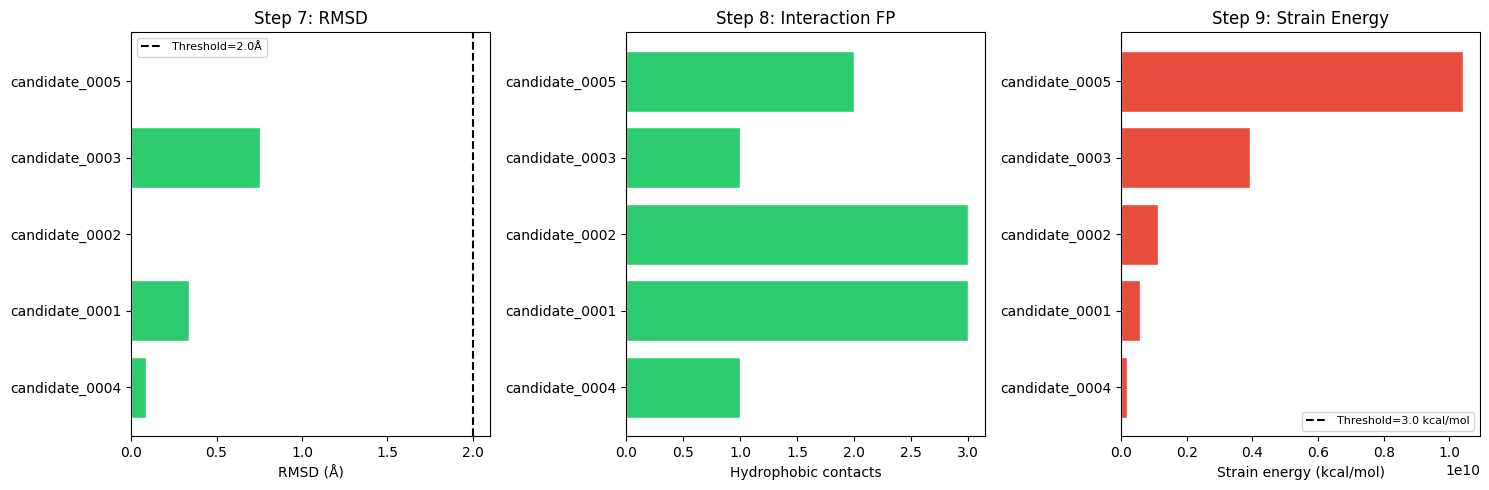

Saved: step3_quality_plot.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names_plot = [r['Molecule'] for r in rows]

# Step 7: RMSD
rmsd_vals = [r['RMSD_A'] if isinstance(r['RMSD_A'], float) else 0 for r in rows]
colors7   = ['#2ecc71' if v < RMSD_THRESHOLD else '#e74c3c' for v in rmsd_vals]
axes[0].barh(names_plot, rmsd_vals, color=colors7, edgecolor='white')
axes[0].axvline(RMSD_THRESHOLD, color='black', linestyle='--',
                label=f'Threshold={RMSD_THRESHOLD}Å')
axes[0].set_xlabel('RMSD (Å)')
axes[0].set_title('Step 7: RMSD')
axes[0].legend(fontsize=8)

# Step 8: Hydrophobic contacts
hydro_vals = [r['Hydrophobic'] for r in rows]
colors8    = ['#2ecc71' if v > 0 else '#e74c3c' for v in hydro_vals]
axes[1].barh(names_plot, hydro_vals, color=colors8, edgecolor='white')
axes[1].set_xlabel('Hydrophobic contacts')
axes[1].set_title('Step 8: Interaction FP')

# Step 9: Strain energy
strain_vals = [r['Strain_kcal'] if isinstance(r['Strain_kcal'], float) else 0 for r in rows]
colors9     = ['#2ecc71' if v < STRAIN_THRESHOLD else '#e74c3c' for v in strain_vals]
axes[2].barh(names_plot, strain_vals, color=colors9, edgecolor='white')
axes[2].axvline(STRAIN_THRESHOLD, color='black', linestyle='--',
                label=f'Threshold={STRAIN_THRESHOLD} kcal/mol')
axes[2].set_xlabel('Strain energy (kcal/mol)')
axes[2].set_title('Step 9: Strain Energy')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/step3_quality_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step3_quality_plot.png')

---
## Export Final Validated Hits

In [11]:
FINAL_SDF = Path('/content/phase3_step3_validated_hits.sdf')
writer    = SDWriter(str(FINAL_SDF))
n_written = 0

for mol, row in zip(hit_mols, rows):
    r7 = rmsd_by_name.get(row['Molecule'], {})
    r8 = fp_by_name.get(row['Molecule'], {})
    r9 = strain_by_name.get(row['Molecule'], {})

    mol.SetProp('Step7_RMSD_A',       str(r7.get('rmsd', 'N/A')))
    mol.SetProp('Step7_RMSD_pass',    str(r7.get('pass', 'N/A')))
    mol.SetProp('Step8_Met_Hbond',    str(r8.get('met_hbond', 'N/A')))
    mol.SetProp('Step8_Hydrophobic',  str(r8.get('n_hydrophobic', 'N/A')))
    mol.SetProp('Step8_FP_pass',      str(r8.get('pass', 'N/A')))
    mol.SetProp('Step9_Strain_kcal',  str(r9.get('strain', 'N/A')))
    mol.SetProp('Step9_Strain_pass',  str(r9.get('pass', 'N/A')))
    mol.SetProp('Step3_OVERALL',      row['OVERALL'])
    writer.write(mol)
    n_written += 1

writer.close()
print(f'✓ {n_written} molecules written to {FINAL_SDF}')
print('  Properties embedded: RMSD, interaction FP, strain energy, overall pass/fail')

✓ 5 molecules written to /content/phase3_step3_validated_hits.sdf
  Properties embedded: RMSD, interaction FP, strain energy, overall pass/fail


---
## Download Outputs

In [12]:
from google.colab import files
for f in [
    '/content/phase3_step3_validated_hits.sdf',
    '/content/step3_pose_quality_results.csv',
    '/content/step3_quality_plot.png',
]:
    if Path(f).exists():
        files.download(f)
        print(f'✓ {Path(f).name}')
    else:
        print(f'✗ Not found: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ phase3_step3_validated_hits.sdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ step3_pose_quality_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ step3_quality_plot.png


---
## Step 3 Complete — Summary

In [13]:
print('=' * 58)
print('  PHASE 3 STEP 3 — POSE QUALITY ASSESSMENT COMPLETE')
print('=' * 58)
print(f'  Step 7 (RMSD < 2Å)          : {sum(1 for r in rmsd_results if r["pass"])}/{len(rmsd_results)} convergent')
print(f'  Step 8 (Interaction FP)      : {sum(1 for r in fingerprint_results if r["pass"])}/{len(fingerprint_results)} pass')
print(f'  Step 9 (Strain < 3 kcal/mol) : {sum(1 for r in strain_results if r["pass"])}/{len(strain_results)} pass')
print(f'  Overall validated hits       : {n_overall}/{len(rows)}')
print(f'  Output SDF                   : phase3_step3_validated_hits.sdf')
print('=' * 58)
print('\nNext: Phase 3 Step 3.3 — GROMACS MD Validation')

  PHASE 3 STEP 3 — POSE QUALITY ASSESSMENT COMPLETE
  Step 7 (RMSD < 2Å)          : 5/5 convergent
  Step 8 (Interaction FP)      : 0/5 pass
  Step 9 (Strain < 3 kcal/mol) : 0/5 pass
  Overall validated hits       : 0/5
  Output SDF                   : phase3_step3_validated_hits.sdf

Next: Phase 3 Step 3.3 — GROMACS MD Validation


---
## Next → GROMACS MD Validation
Validated hits from this step feed into GROMACS for:
- NVT/NPT equilibration
- 100ns production MD
- αC-helix salt bridge distance monitoring (> 5Å = inactive state stabilised)
- Ligand RMSD stability analysis
- MM/PBSA binding free energy estimation